In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load dataset
df = pd.read_csv("mental_health.csv")

# Display first rows
df.head()

,Age,Gender,Country,Education,Marital_Status,Income_Level,Employment_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,...,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Discuss_Mental_Health,Has_Mental_Health_Issue
0,40,Male,USA,Some College,Single,Middle,Full-time,27,No,6,...,1,0,0,0,9,3,4,6,Sometimes,1
1,33,Male,India,Bachelor,Married,Middle,Unemployed,47,No,6,...,0,0,0,0,3,2,7,7,Sometimes,1
2,42,Male,Other,High School,Single,Low,Full-time,53,No,1,...,1,0,0,1,5,3,6,9,Sometimes,1
3,53,Male,Germany,Bachelor,Single,Middle,Unemployed,42,No,10,...,0,1,0,0,1,3,10,5,Never,1
4,32,Female,India,Bachelor,Single,High,Student,13,No,4,...,0,0,0,0,1,5,1,6,Sometimes,1


In [2]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset info:")
df.info()

Dataset shape: (10000, 51)

Columns:
Index(['Age', 'Gender', 'Country', 'Education', 'Marital_Status',
       'Income_Level', 'Employment_Status', 'Work_Hours_Per_Week',
       'Remote_Work', 'Job_Satisfaction', 'Work_Stress_Level',
       'Work_Life_Balance', 'Ever_Bullied_At_Work',
       'Company_Mental_Health_Support', 'Exercise_Per_Week',
       'Sleep_Hours_Night', 'Caffeine_Drinks_Day', 'Alcohol_Frequency',
       'Smoking', 'Screen_Time_Hours_Day', 'Social_Media_Hours_Day',
       'Hobby_Time_Hours_Week', 'Diet_Quality', 'Financial_Stress',
       'Feeling_Sad_Down', 'Loss_Of_Interest', 'Sleep_Trouble', 'Fatigue',
       'Poor_Appetite_Or_Overeating', 'Feeling_Worthless',
       'Concentration_Difficulty', 'Anxious_Nervous', 'Panic_Attacks',
       'Mood_Swings', 'Irritability', 'Obsessive_Thoughts',
       'Compulsive_Behavior', 'Self_Harm_Thoughts', 'Suicidal_Thoughts',
       'Family_History_Mental_Illness', 'Previously_Diagnosed',
       'Ever_Sought_Treatment', 'On_Therapy

In [3]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

print("Missing values:")
print(missing_values)

if missing_values.empty:
    print("No missing values found.")

Missing values:
Series([], dtype: int64)
No missing values found.


In [4]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Remove duplicates if found
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (10000, 51)


In [5]:
target = "Has_Mental_Health_Issue"

print(df[target].value_counts())
print(df[target].value_counts(normalize=True) * 100)

1    9216
0     784
Name: Has_Mental_Health_Issue, dtype: int64
1    92.16
0     7.84
Name: Has_Mental_Health_Issue, dtype: float64


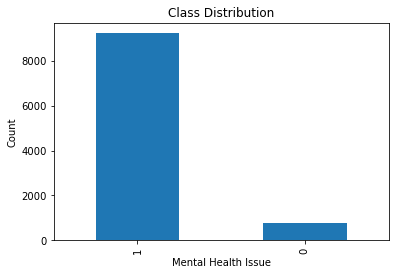

In [6]:
df[target].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Mental Health Issue")
plt.ylabel("Count")
plt.show()

In [7]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

statistical_analysis = df[numeric_cols].agg(["mean", "median", "std", "min", "max"]).T
statistical_analysis

,mean,median,std,min,max
Age,34.94790,34.0,11.156390,18.0,75.0
Work_Hours_Per_Week,39.65790,40.0,10.016711,0.0,74.0
Job_Satisfaction,5.50270,6.0,2.884341,1.0,10.0
Work_Stress_Level,5.49390,6.0,2.881630,1.0,10.0
Work_Life_Balance,5.48940,5.0,2.875572,1.0,10.0
Ever_Bullied_At_Work,0.24740,0.0,0.431523,0.0,1.0
Sleep_Hours_Night,6.81545,6.8,1.377975,3.0,11.0
Caffeine_Drinks_Day,2.02330,2.0,1.427432,0.0,8.0
Screen_Time_Hours_Day,7.06459,7.0,2.955874,1.0,16.0
Social_Media_Hours_Day,3.14181,3.0,2.254204,0.0,12.0


In [8]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 Gender
Female               4892
Male                 4676
Non-binary            316
Prefer not to say     116
Name: Gender, dtype: int64

 Country
USA        2519
India      2033
Other      1945
UK         1458
Brazil     1077
Germany     968
Name: Country, dtype: int64

 Education
Bachelor        3493
Some College    2517
High School     1991
Master          1514
PhD              485
Name: Education, dtype: int64

 Marital_Status
Single      4523
Married     3982
Divorced    1227
Widowed      268
Name: Marital_Status, dtype: int64

 Income_Level
Middle    5059
Low       2951
High      1990
Name: Income_Level, dtype: int64

 Employment_Status
Full-time        4473
Student          2021
Part-time        1537
Unemployed       1232
Self-employed     737
Name: Employment_Status, dtype: int64

 Remote_Work
No        4958
Yes       3099
Hybrid    1943
Name: Remote_Work, dtype: int64

 Company_Mental_Health_Support
No          5526
Yes         2519
Not sure    1955
Name: Company_Mental_Hea

In [9]:
correlation_with_target = df[numeric_cols].corr()[target].sort_values(ascending=False)
correlation_with_target

Has_Mental_Health_Issue          1.000000
Work_Stress_Level                0.055028
Family_History_Mental_Illness    0.054693
Feeling_Sad_Down                 0.050075
Financial_Stress                 0.045807
Anxious_Nervous                  0.043630
Poor_Appetite_Or_Overeating      0.040525
Loneliness                       0.040237
Suicidal_Thoughts                0.038835
Trauma_History                   0.038176
Fatigue                          0.033911
Irritability                     0.033130
Compulsive_Behavior              0.031555
Obsessive_Thoughts               0.031200
Concentration_Difficulty         0.031196
Feeling_Worthless                0.030927
Self_Harm_Thoughts               0.029435
Mood_Swings                      0.027499
On_Medication                    0.022540
Sleep_Trouble                    0.021354
Work_Hours_Per_Week              0.020755
Loss_Of_Interest                 0.020239
Previously_Diagnosed             0.015017
Hobby_Time_Hours_Week            0

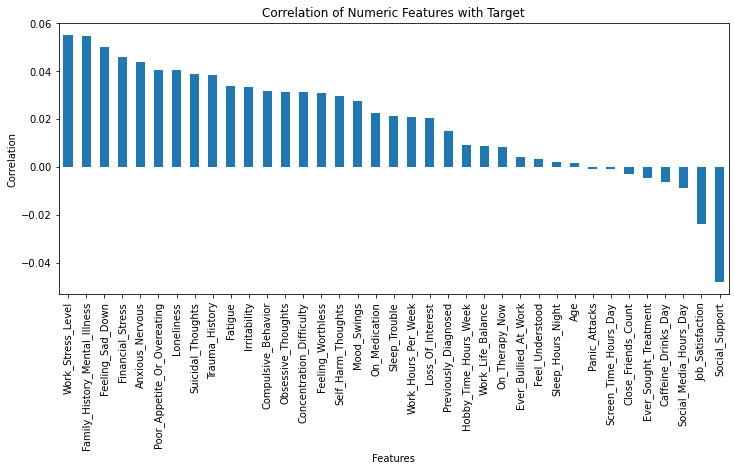

In [10]:
correlation_with_target.drop(target).plot(kind="bar", figsize=(12,5))
plt.title("Correlation of Numeric Features with Target")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.show()

In [11]:
X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 50)
y shape: (10000,)


In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 37
Index(['Age', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Stress_Level',
       'Work_Life_Balance', 'Ever_Bullied_At_Work', 'Sleep_Hours_Night',
       'Caffeine_Drinks_Day', 'Screen_Time_Hours_Day',
       'Social_Media_Hours_Day', 'Hobby_Time_Hours_Week', 'Financial_Stress',
       'Feeling_Sad_Down', 'Loss_Of_Interest', 'Sleep_Trouble', 'Fatigue',
       'Poor_Appetite_Or_Overeating', 'Feeling_Worthless',
       'Concentration_Difficulty', 'Anxious_Nervous', 'Panic_Attacks',
       'Mood_Swings', 'Irritability', 'Obsessive_Thoughts',
       'Compulsive_Behavior', 'Self_Harm_Thoughts', 'Suicidal_Thoughts',
       'Family_History_Mental_Illness', 'Previously_Diagnosed',
       'Ever_Sought_Treatment', 'On_Therapy_Now', 'On_Medication',
       'Trauma_History', 'Social_Support', 'Close_Friends_Count',
       'Feel_Understood', 'Loneliness'],
      dtype='object')

Categorical features: 13
Index(['Gender', 'Country', 'Education', 'Marital_Status', 'Income_Leve

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 50)
X_test: (2000, 50)
y_train: (8000,)
y_test: (2000,)


In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (8000, 89)
Processed X_test shape: (2000, 89)


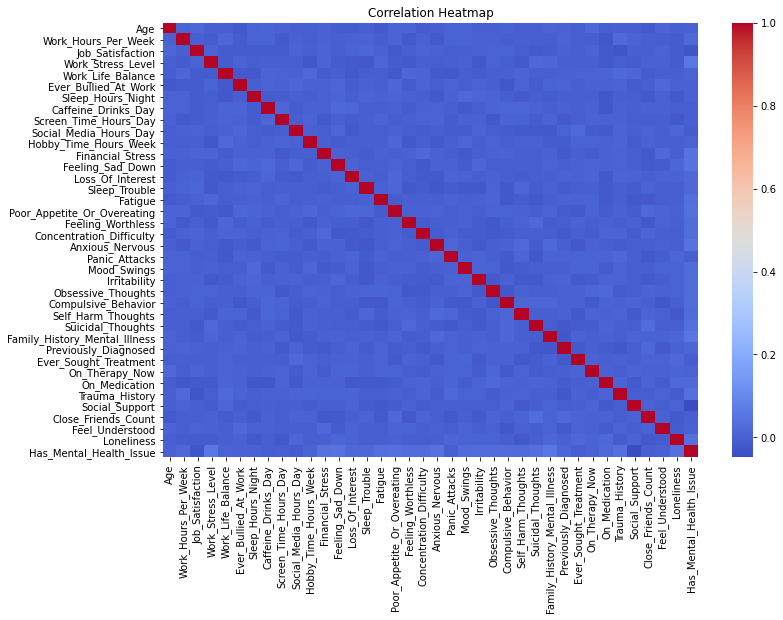

In [16]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()